# 🎓 College Placement Analysis Using Python

### Project Overview
This project analyzes student placement data and identifies factors affecting placements such as CGPA, Branch, Internships, Gender, and Salary Packages.

### Objectives
- Analyze student placement trends
- Perform data visualization
- Identify placement patterns
- Build a Machine Learning model for placement prediction
- Evaluate model performance

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn
- Jupyter Notebook

### Dataset Details
- Total Students: 100
- Features: Student_ID, Gender, Branch, CGPA, Internships, Placement_Status, Salary

# 📥 Step 1: Import Required Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 📂 Step 2: Load Dataset

In [3]:
df = pd.read_csv(
    r"C:\Users\gango\OneDrive\Desktop\College_Placement_Analysis\placement_data.csv"
)

df.head()

,Student_ID,Gender,Branch,CGPA,Internships,Placement_Status,Salary
0,1,Male,CSE,8.5,2,Placed,650000
1,2,Female,ECE,9.1,3,Placed,800000
2,3,Male,MECH,7.2,1,Not Placed,0
3,4,Female,CSE,8.9,2,Placed,750000
4,5,Male,EEE,6.8,0,Not Placed,0


# 📊 Step 3: Dataset Understanding

In [4]:
df.shape

(100, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        100 non-null    int64  
 1   Gender            100 non-null    object 
 2   Branch            100 non-null    object 
 3   CGPA              100 non-null    float64
 4   Internships       100 non-null    int64  
 5   Placement_Status  100 non-null    object 
 6   Salary            100 non-null    int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.6+ KB


In [6]:
df.isnull().sum()

Student_ID          0
Gender              0
Branch              0
CGPA                0
Internships         0
Placement_Status    0
Salary              0
dtype: int64

In [7]:
df.describe()

,Student_ID,CGPA,Internships,Salary
count,100.000000,100.000000,100.000000,100.000000
mean,50.500000,8.154000,1.760000,522500.000000
std,29.011492,0.769418,1.035921,309464.754606
min,1.000000,6.500000,0.000000,0.000000
25%,25.750000,7.775000,1.000000,507500.000000
50%,50.500000,8.250000,2.000000,600000.000000
75%,75.250000,8.700000,2.000000,712500.000000
max,100.000000,9.400000,4.000000,980000.000000


# 📈 Step 4: Exploratory Data Analysis (EDA)

In [8]:
df["Placement_Status"].value_counts()

Placement_Status
Placed        77
Not Placed    23
Name: count, dtype: int64

In [9]:
df["Branch"].value_counts()

Branch
CSE     33
ECE     25
MECH    22
EEE     20
Name: count, dtype: int64

In [10]:
df["Gender"].value_counts()

Gender
Male      50
Female    50
Name: count, dtype: int64

# 📊 Step 5: Data Visualization

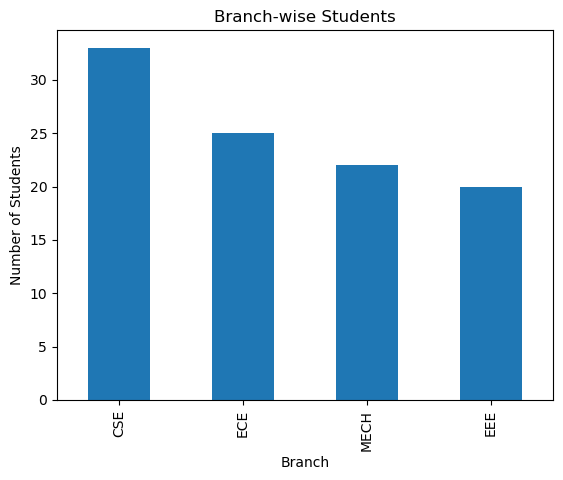

In [11]:
df["Branch"].value_counts().plot(kind="bar")

plt.title("Branch-wise Students")
plt.xlabel("Branch")
plt.ylabel("Number of Students")

plt.show()

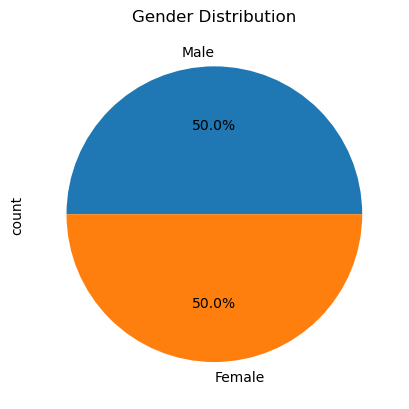

In [12]:
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

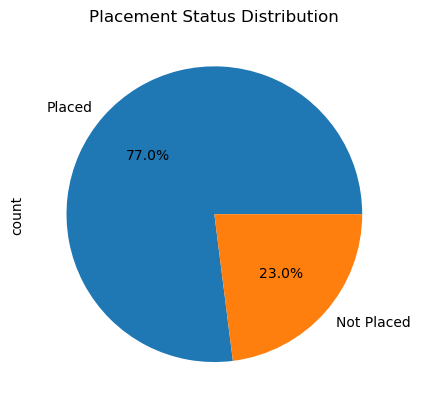

In [13]:
df["Placement_Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Placement Status Distribution")

plt.show()

In [15]:
top_students = df.sort_values(
    by="Salary",
    ascending=False
)

top_students.head(10)

,Student_ID,Gender,Branch,CGPA,Internships,Placement_Status,Salary
97,98,Female,CSE,9.4,4,Placed,980000
69,70,Female,CSE,9.4,4,Placed,970000
29,30,Female,CSE,9.4,4,Placed,950000
87,88,Female,CSE,9.3,4,Placed,930000
47,48,Female,CSE,9.3,4,Placed,920000
5,6,Female,CSE,9.3,4,Placed,900000
93,94,Female,CSE,9.2,3,Placed,900000
57,58,Female,CSE,9.2,3,Placed,890000
23,24,Female,CSE,9.2,3,Placed,880000
35,36,Female,CSE,9.1,3,Placed,870000


# 🤖 Step 6: Machine Learning Model

In [16]:
branch_mapping = {
    "CSE": 0,
    "ECE": 1,
    "EEE": 2,
    "MECH": 3
}

df_ml = df.copy()

df_ml["Placement_Status"] = df_ml["Placement_Status"].map({
    "Placed": 1,
    "Not Placed": 0
})

df_ml["Branch"] = df_ml["Branch"].map(branch_mapping)

df_ml.head()

,Student_ID,Gender,Branch,CGPA,Internships,Placement_Status,Salary
0,1,Male,0,8.5,2,1,650000
1,2,Female,1,9.1,3,1,800000
2,3,Male,3,7.2,1,0,0
3,4,Female,0,8.9,2,1,750000
4,5,Male,2,6.8,0,0,0


In [26]:
X = df_ml[["CGPA", "Internships", "Branch"]]

y = df_ml["Placement_Status"]

In [27]:
X.head()

,CGPA,Internships,Branch
0,8.5,2,CSE
1,9.1,3,ECE
2,7.2,1,MECH
3,8.9,2,CSE
4,6.8,0,EEE


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
X_train.shape, X_test.shape

((80, 3), (20, 3))

In [33]:
df_ml["Branch"].unique()

array([0, 1, 3, 2])

In [35]:
X = df_ml[["CGPA", "Internships", "Branch"]]

y = df_ml["Placement_Status"]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance

,Feature,Importance
0,CGPA,0.447369
1,Internships,0.188235
2,Branch,0.364395


In [40]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,CGPA,0.447369
2,Branch,0.364395
1,Internships,0.188235


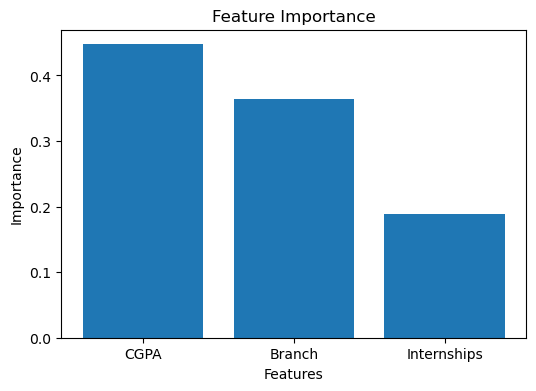

In [41]:
plt.figure(figsize=(6,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

# 🎯 Conclusion

This College Placement Analysis project was successfully completed using Python, Pandas, NumPy, Matplotlib, and Scikit-Learn.

### Key Findings:
- Analyzed placement data of 100 students.
- Studied branch-wise and gender-wise placement trends.
- Analyzed salary distribution among placed students.
- Visualized placement statistics using charts and graphs.
- Built a Machine Learning model using Random Forest Classifier.
- Predicted student placement chances based on CGPA, Internships, and Branch.
- Evaluated model performance using accuracy and feature importance analysis.

### Outcome:
The project helps understand factors affecting student placements and provides a simple prediction system for estimating placement chances.

## Thank You